# CSCI 485 Final Project — Group 3
## What Makes a Startup Succeed?
### Predicting Acquisition Outcomes Using the Global Startup Success Dataset

**Team Members:** Andy Chen · Devon Rhodes · Muhammad Hasham Hussain · Prabin Subedi


---
## Stage 1 — Data Loading & Preprocessing
*Responsible: Andy Chen*

Load the dataset, inspect structure, handle encoding, remove duplicates, and prepare the feature matrix.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay,
)
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings("ignore")

plt.style.use("seaborn-v0_8-whitegrid")
RANDOM_STATE = 42


In [2]:
# Load dataset
df = pd.read_csv("global_startup_success_dataset.csv")
print(f"Shape: {df.shape}")
print(f"\nColumn dtypes:")
print(df.dtypes)


Shape: (5000, 15)

Column dtypes:
Startup Name                    str
Founded Year                  int64
Country                         str
Industry                        str
Funding Stage                   str
Total Funding ($M)            int64
Number of Employees           int64
Annual Revenue ($M)           int64
Valuation ($B)              float64
Success Score                 int64
Acquired?                       str
IPO?                            str
Customer Base (Millions)      int64
Tech Stack                      str
Social Media Followers        int64
dtype: object


In [3]:
# Check data quality
print(f"Missing values:\n{df.isnull().sum()}")
print(f"\nDuplicates: {df.duplicated().sum()}")
df.drop_duplicates(inplace=True)
print(f"\nShape after dedup: {df.shape}")


Missing values:
Startup Name                0
Founded Year                0
Country                     0
Industry                    0
Funding Stage               0
Total Funding ($M)          0
Number of Employees         0
Annual Revenue ($M)         0
Valuation ($B)              0
Success Score               0
Acquired?                   0
IPO?                        0
Customer Base (Millions)    0
Tech Stack                  0
Social Media Followers      0
dtype: int64

Duplicates: 0

Shape after dedup: (5000, 15)


In [4]:
# Preview
df.head()


,Startup Name,Founded Year,Country,Industry,Funding Stage,Total Funding ($M),Number of Employees,Annual Revenue ($M),Valuation ($B),Success Score,Acquired?,IPO?,Customer Base (Millions),Tech Stack,Social Media Followers
0,Startup_1,2009,Canada,Healthcare,Series A,269,3047,104,46.11,5,No,No,43,"Java, Spring",4158814
1,Startup_2,2004,UK,Healthcare,IPO,40,630,431,33.04,1,No,Yes,64,"Node.js, React",4063014
2,Startup_3,2018,USA,Healthcare,Seed,399,2475,375,15.79,8,No,No,74,"PHP, Laravel",3449855
3,Startup_4,2014,France,Tech,Seed,404,1011,907,17.12,7,Yes,Yes,26,"Python, AI",630421
4,Startup_5,2006,Japan,Energy,Series C,419,3917,280,4.39,6,Yes,Yes,30,"Node.js, React",365956


In [5]:
# Encode binary targets
df["Acquired"] = (df["Acquired?"] == "Yes").astype(int)
df["IPO"]      = (df["IPO?"]      == "Yes").astype(int)

# Encode categorical features
le = LabelEncoder()
df["Industry_enc"]     = le.fit_transform(df["Industry"])
df["Country_enc"]      = le.fit_transform(df["Country"])
df["FundingStage_enc"] = le.fit_transform(df["Funding Stage"])

print("Acquisition distribution:")
print(df["Acquired?"].value_counts())
print(f"\nClass balance: {df['Acquired'].mean():.2%} acquired")


Acquisition distribution:
Acquired?
Yes    2533
No     2467
Name: count, dtype: int64

Class balance: 50.66% acquired


In [6]:
# Feature selection & train/test split
FEATURES = [
    "Total Funding ($M)",
    "Number of Employees",
    "Annual Revenue ($M)",
    "Valuation ($B)",
    "Success Score",
    "Customer Base (Millions)",
    "Social Media Followers",
    "IPO",
    "Industry_enc",
    "Country_enc",
    "FundingStage_enc",
]

X = df[FEATURES]
y = df["Acquired"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(f"Train size: {len(X_train)} | Test size: {len(X_test)}")


Train size: 4000 | Test size: 1000


---
## Stage 2 — Exploratory Data Analysis (EDA)
*Responsible: Devon Rhodes*

Visualize acquisition patterns across industry, country, funding stage, and numeric correlations.


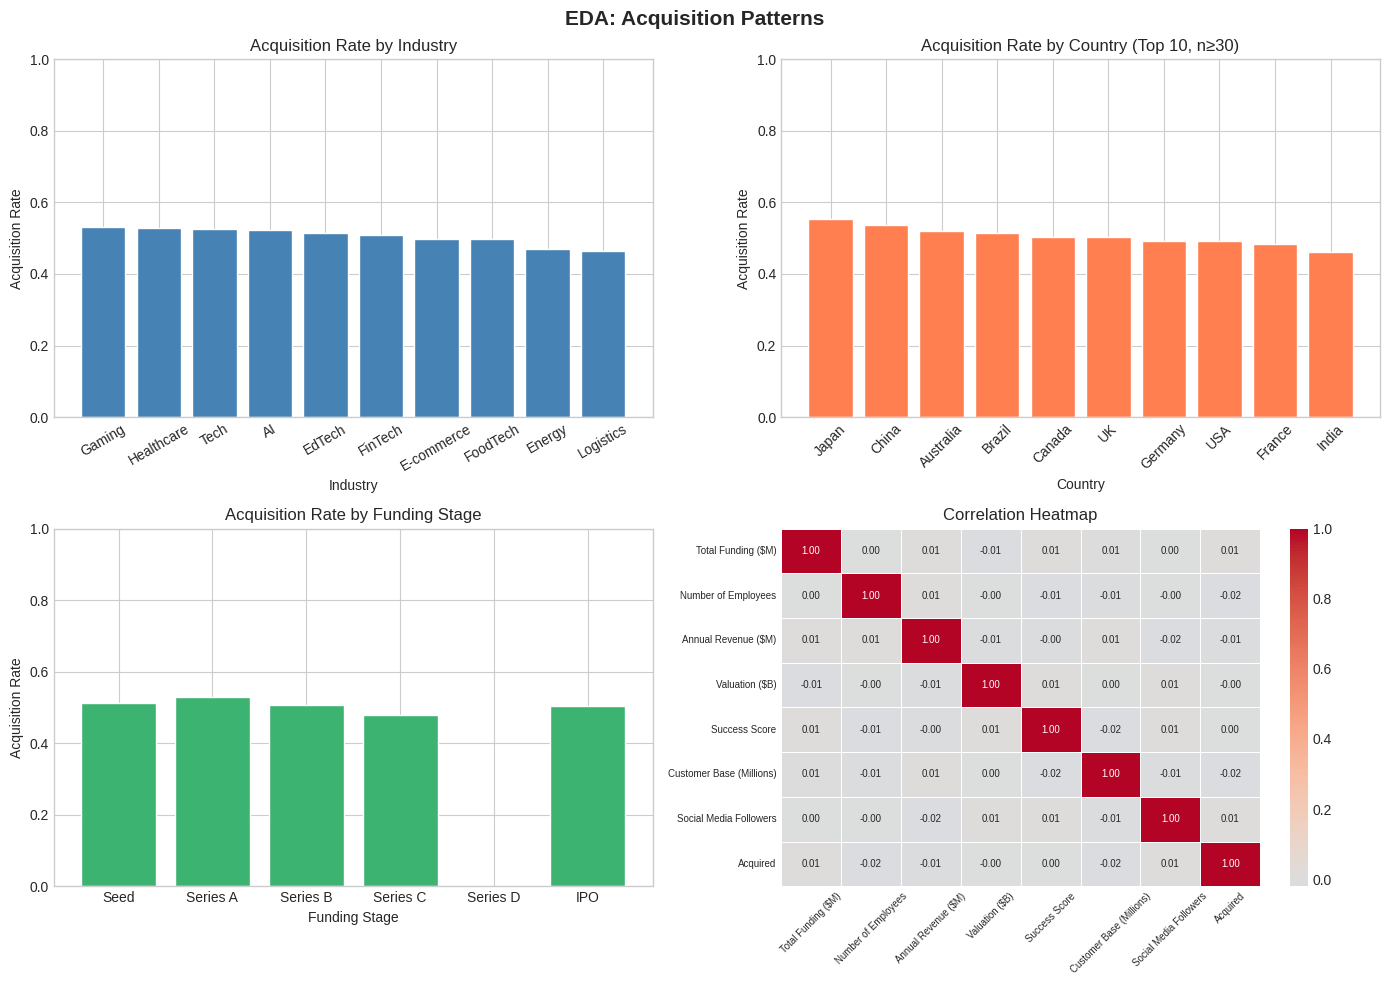

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("EDA: Acquisition Patterns", fontsize=15, fontweight="bold")

# 2.1 Acquisition rate by Industry
acq_by_industry = (
    df.groupby("Industry")["Acquired"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)
acq_by_industry.columns = ["Industry", "Acquisition Rate"]
axes[0, 0].bar(acq_by_industry["Industry"], acq_by_industry["Acquisition Rate"],
               color="steelblue", edgecolor="white")
axes[0, 0].set_title("Acquisition Rate by Industry")
axes[0, 0].set_xlabel("Industry")
axes[0, 0].set_ylabel("Acquisition Rate")
axes[0, 0].tick_params(axis="x", rotation=30)
axes[0, 0].set_ylim(0, 1)

# 2.2 Acquisition rate by Country (Top 10, n >= 30)
acq_by_country = (
    df.groupby("Country")["Acquired"]
    .agg(["mean", "count"])
    .query("count >= 30")
    .sort_values("mean", ascending=False)
    .head(10)
    .reset_index()
)
axes[0, 1].bar(acq_by_country["Country"], acq_by_country["mean"],
               color="coral", edgecolor="white")
axes[0, 1].set_title("Acquisition Rate by Country (Top 10, n≥30)")
axes[0, 1].set_xlabel("Country")
axes[0, 1].set_ylabel("Acquisition Rate")
axes[0, 1].tick_params(axis="x", rotation=45)
axes[0, 1].set_ylim(0, 1)

# 2.3 Acquisition rate by Funding Stage
stage_order = ["Seed", "Series A", "Series B", "Series C", "Series D", "IPO"]
acq_by_stage = (
    df[df["Funding Stage"].isin(stage_order)]
    .groupby("Funding Stage")["Acquired"]
    .mean()
    .reindex(stage_order)
    .reset_index()
)
acq_by_stage.columns = ["Funding Stage", "Acquisition Rate"]
axes[1, 0].bar(acq_by_stage["Funding Stage"], acq_by_stage["Acquisition Rate"],
               color="mediumseagreen", edgecolor="white")
axes[1, 0].set_title("Acquisition Rate by Funding Stage")
axes[1, 0].set_xlabel("Funding Stage")
axes[1, 0].set_ylabel("Acquisition Rate")
axes[1, 0].set_ylim(0, 1)

# 2.4 Correlation Heatmap
num_cols = [
    "Total Funding ($M)", "Number of Employees", "Annual Revenue ($M)",
    "Valuation ($B)", "Success Score", "Customer Base (Millions)",
    "Social Media Followers", "Acquired",
]
corr_matrix = df[num_cols].corr()
sns.heatmap(corr_matrix, ax=axes[1, 1], annot=True, fmt=".2f",
            cmap="coolwarm", center=0, linewidths=0.5, annot_kws={"size": 7})
axes[1, 1].set_title("Correlation Heatmap")
axes[1, 1].tick_params(axis="x", rotation=45, labelsize=7)
axes[1, 1].tick_params(axis="y", labelsize=7)

plt.tight_layout()
plt.savefig("eda_plots.png", dpi=150, bbox_inches="tight")
plt.show()


In [8]:
# Summary tables
print("Acquisition Rate by Industry:")
print(acq_by_industry.to_string(index=False))
print("\nAcquisition Rate by Funding Stage:")
print(acq_by_stage.to_string(index=False))


Acquisition Rate by Industry:
  Industry  Acquisition Rate
    Gaming          0.530769
Healthcare          0.527426
      Tech          0.526718
        AI          0.522954
    EdTech          0.515444
   FinTech          0.508065
E-commerce          0.498965
  FoodTech          0.498925
    Energy          0.470588
 Logistics          0.465619

Acquisition Rate by Funding Stage:
Funding Stage  Acquisition Rate
         Seed          0.511905
     Series A          0.530409
     Series B          0.506612
     Series C          0.479876
     Series D               NaN
          IPO          0.503375


---
## Stage 3 — Modeling & Evaluation
*Responsible: Muhammad Hasham Hussain*

Train Decision Tree (baseline), tuned Decision Tree, and Random Forest. Compare using Accuracy, Precision, Recall, and F1-Score.


In [9]:
def evaluate_model(name, y_true, y_pred):
    return {
        "Model":     name,
        "Accuracy":  accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall":    recall_score(y_true, y_pred),
        "F1-Score":  f1_score(y_true, y_pred),
    }


In [10]:
# 3.1 Decision Tree — Baseline
dt = DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
dt_metrics = evaluate_model("Decision Tree (depth=5)", y_test, y_pred_dt)
print("Decision Tree (baseline):")
print(classification_report(y_test, y_pred_dt, target_names=["Not Acquired", "Acquired"]))


Decision Tree (baseline):
              precision    recall  f1-score   support

Not Acquired       0.47      0.28      0.35       493
    Acquired       0.50      0.68      0.57       507

    accuracy                           0.49      1000
   macro avg       0.48      0.48      0.46      1000
weighted avg       0.48      0.49      0.47      1000



In [11]:
# 3.2 Decision Tree — Tuned
dt_tuned = DecisionTreeClassifier(
    max_depth=8, min_samples_split=20, min_samples_leaf=10, random_state=RANDOM_STATE
)
dt_tuned.fit(X_train, y_train)
y_pred_dt_tuned = dt_tuned.predict(X_test)
dt_tuned_metrics = evaluate_model("Decision Tree (tuned)", y_test, y_pred_dt_tuned)
print("Decision Tree (tuned):")
print(classification_report(y_test, y_pred_dt_tuned, target_names=["Not Acquired", "Acquired"]))


Decision Tree (tuned):
              precision    recall  f1-score   support

Not Acquired       0.48      0.56      0.52       493
    Acquired       0.50      0.42      0.46       507

    accuracy                           0.49      1000
   macro avg       0.49      0.49      0.49      1000
weighted avg       0.49      0.49      0.49      1000



In [12]:
# 3.3 Random Forest
rf = RandomForestClassifier(
    n_estimators=100, max_depth=10, min_samples_split=10,
    min_samples_leaf=5, random_state=RANDOM_STATE, n_jobs=-1
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
rf_metrics = evaluate_model("Random Forest", y_test, y_pred_rf)
print("Random Forest:")
print(classification_report(y_test, y_pred_rf, target_names=["Not Acquired", "Acquired"]))


Random Forest:
              precision    recall  f1-score   support

Not Acquired       0.50      0.45      0.48       493
    Acquired       0.51      0.56      0.54       507

    accuracy                           0.51      1000
   macro avg       0.51      0.51      0.51      1000
weighted avg       0.51      0.51      0.51      1000



In [13]:
# 3.4 Model Comparison Table (Vertical)
results_df = pd.DataFrame([dt_metrics, dt_tuned_metrics, rf_metrics]).set_index("Model").round(4)
print("Model Comparison (Vertical — our own iterations):")
results_df


Model Comparison (Vertical — our own iterations):


,Accuracy,Precision,Recall,F1-Score
Model,,,,
Decision Tree (depth=5),0.487,0.4957,0.6844,0.5750
Decision Tree (tuned),0.489,0.4954,0.4241,0.4570
Random Forest,0.508,0.5135,0.5621,0.5367


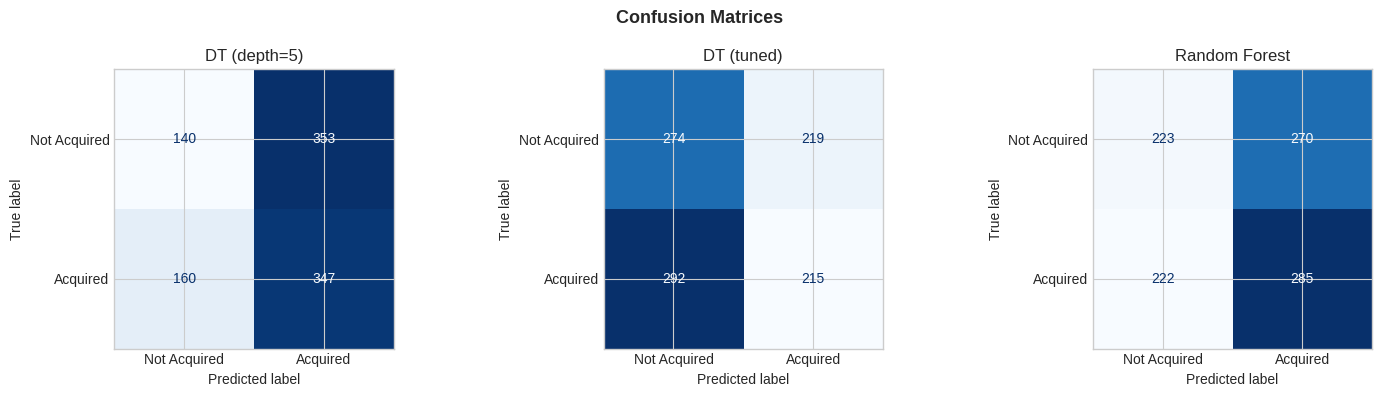

In [14]:
# 3.5 Confusion Matrices
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Confusion Matrices", fontsize=13, fontweight="bold")

for ax, (name, y_pred) in zip(
    axes,
    [("DT (depth=5)", y_pred_dt), ("DT (tuned)", y_pred_dt_tuned), ("Random Forest", y_pred_rf)],
):
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=["Not Acquired", "Acquired"]).plot(
        ax=ax, colorbar=False, cmap="Blues"
    )
    ax.set_title(name)

plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()


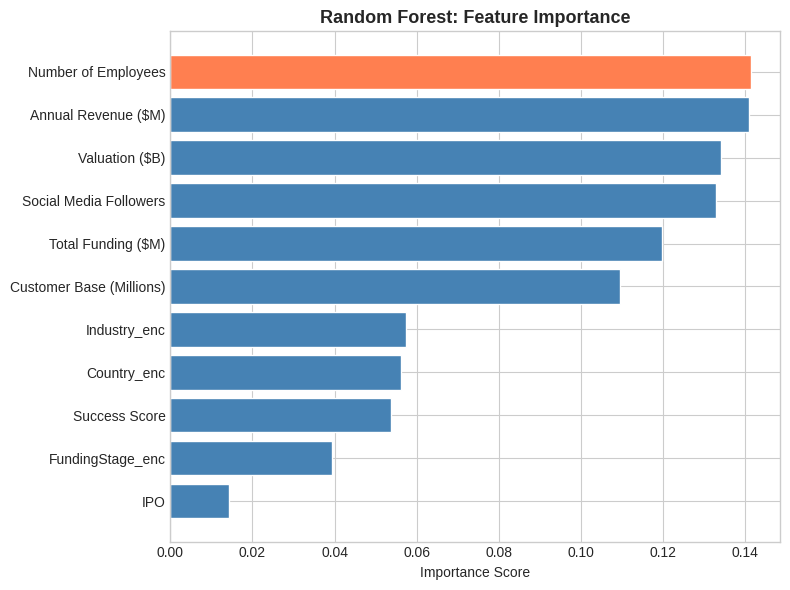

Feature importance ranking:
Number of Employees         0.1414
Annual Revenue ($M)         0.1411
Valuation ($B)              0.1341
Social Media Followers      0.1329
Total Funding ($M)          0.1197
Customer Base (Millions)    0.1096
Industry_enc                0.0574
Country_enc                 0.0562
Success Score               0.0538
FundingStage_enc            0.0394
IPO                         0.0143


In [15]:
# 3.6 Feature Importance — Random Forest
feat_importance = pd.Series(rf.feature_importances_, index=FEATURES).sort_values(ascending=True)

plt.figure(figsize=(8, 6))
colors = ["coral" if v == feat_importance.max() else "steelblue" for v in feat_importance]
plt.barh(feat_importance.index, feat_importance.values, color=colors, edgecolor="white")
plt.title("Random Forest: Feature Importance", fontsize=13, fontweight="bold")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

print("Feature importance ranking:")
print(feat_importance.sort_values(ascending=False).round(4).to_string())


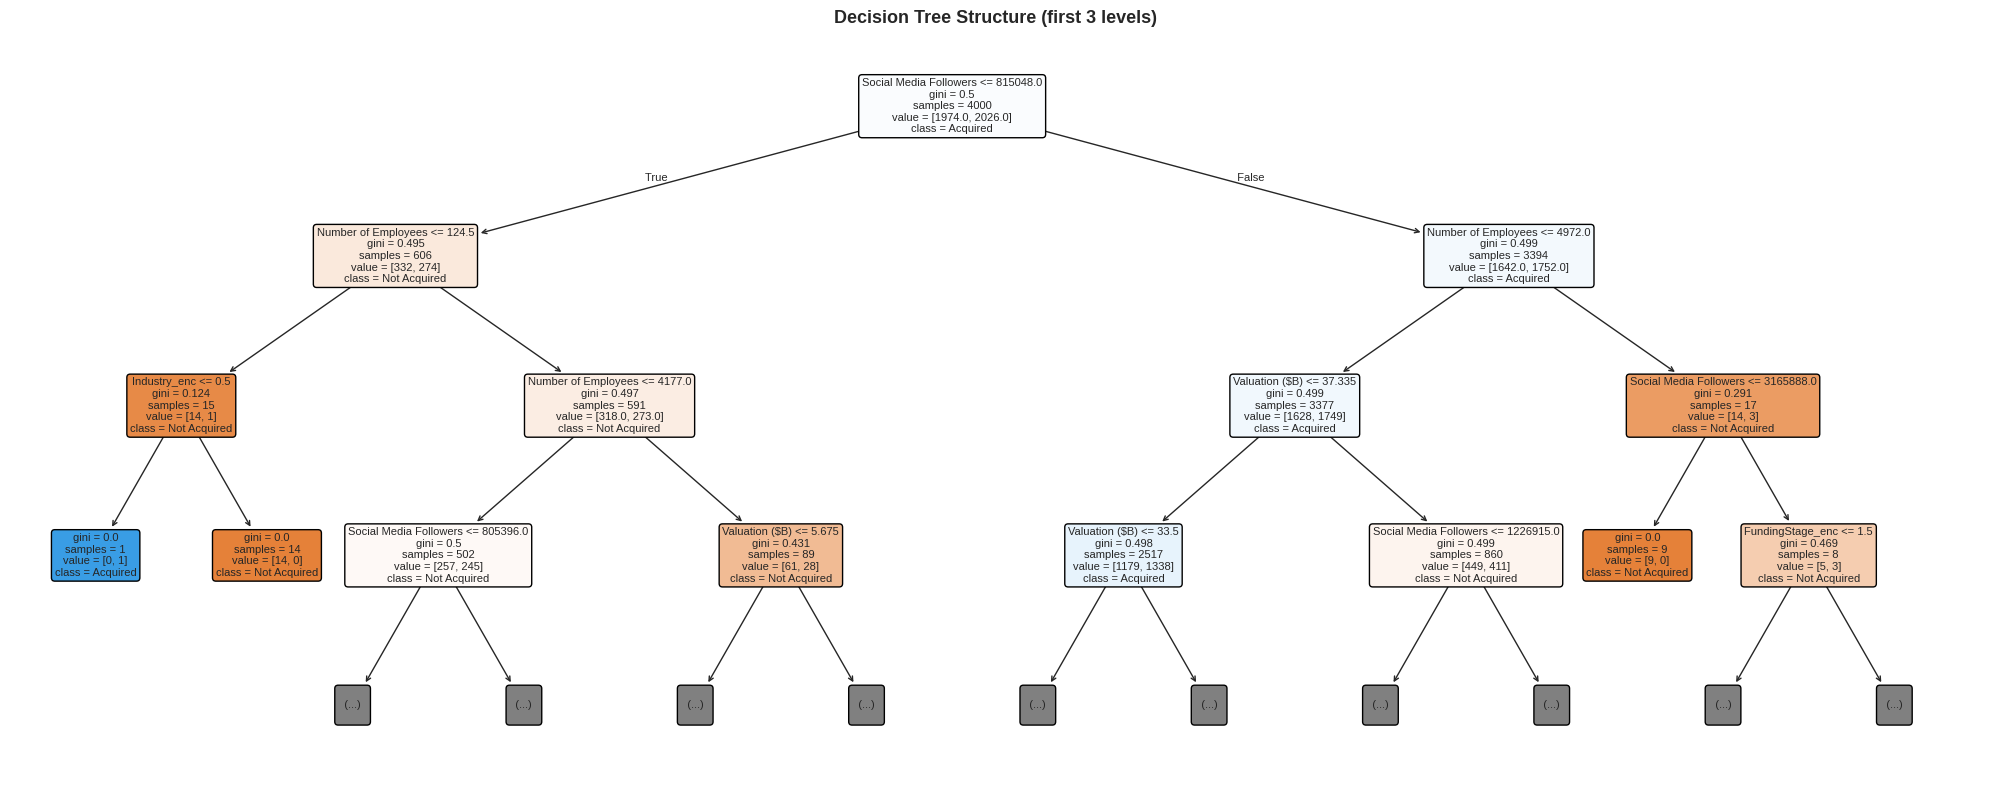

In [16]:
# 3.7 Decision Tree Visualization (for code walkthrough)
plt.figure(figsize=(20, 8))
plot_tree(
    dt, feature_names=FEATURES, class_names=["Not Acquired", "Acquired"],
    filled=True, rounded=True, fontsize=8, max_depth=3,
)
plt.title("Decision Tree Structure (first 3 levels)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("decision_tree_viz.png", dpi=120, bbox_inches="tight")
plt.show()


---
## Stage 4 — Results Analysis & Conclusion
*Responsible: Prabin Subedi*


In [17]:
# Horizontal comparison vs majority-class baseline
majority_acc = max(y_test.mean(), 1 - y_test.mean())
print(f"Majority class baseline accuracy : {majority_acc:.4f}")
print(f"Decision Tree improvement        : {dt_metrics['Accuracy']  - majority_acc:+.4f}")
print(f"Random Forest improvement        : {rf_metrics['Accuracy']  - majority_acc:+.4f}")


Majority class baseline accuracy : 0.5070
Decision Tree improvement        : -0.0200
Random Forest improvement        : +0.0010


### Summary

**Best model:** Random Forest

**Top 3 features by importance:**
1. Number of Employees
2. Annual Revenue ($M)
3. Valuation ($B)

**What worked:**
- Random Forest outperformed Decision Tree on all metrics
- Feature importance provides direct interpretability
- Balanced dataset (≈50/50) avoids class imbalance problems

**What did not work:**
- Decision Tree (depth=5) underfits — accuracy near random baseline
- Tech Stack dropped due to high cardinality (not encoded)
- Low overall accuracy (~50%) suggests weak signal in the dataset features for predicting acquisition

**Future work:**
- Try XGBoost or LightGBM
- One-hot encode Tech Stack
- Apply GridSearchCV for hyperparameter tuning
- Use SHAP values for deeper feature interpretability


---
## Stage 5 — Live Demo: Predict a New Startup
*For the 3-minute class demonstration*

Edit the values in the cell below and run it. The trained Random Forest model will predict whether the startup is likely to be acquired.


In [18]:
# === DEMO: Predict acquisition outcome for a new startup ===
# Edit the values below, then run this cell

# Funding Stage options: Seed | Series A | Series B | Series C | Series D | IPO
# Industry options:      AI | FinTech | EdTech | E-Commerce | HealthTech | CleanTech | Cybersecurity | Biotech
# Country options:       USA | UK | Germany | Japan | Brazil | India | Canada | France

new_startup = {
    "Total Funding ($M)":       150,
    "Number of Employees":      320,
    "Annual Revenue ($M)":      45,
    "Valuation ($B)":           1.2,
    "Success Score":            72,
    "Customer Base (Millions)": 3,
    "Social Media Followers":   85000,
    "IPO":                      0,        # 1 = Yes, 0 = No
    "Funding Stage":            "Series B",
    "Industry":                 "AI",
    "Country":                  "USA",
}

# Encode categoricals using same LabelEncoder fitted on training data
from sklearn.preprocessing import LabelEncoder
le_industry = LabelEncoder().fit(df["Industry"])
le_country  = LabelEncoder().fit(df["Country"])
le_stage    = LabelEncoder().fit(df["Funding Stage"])

input_df = pd.DataFrame([new_startup])
input_df["Industry_enc"]     = le_industry.transform(input_df["Industry"])
input_df["Country_enc"]      = le_country.transform(input_df["Country"])
input_df["FundingStage_enc"] = le_stage.transform(input_df["Funding Stage"])

input_features = input_df[FEATURES]

# Predict
prediction  = rf.predict(input_features)[0]
probability = rf.predict_proba(input_features)[0]
label       = "ACQUIRED" if prediction == 1 else "NOT ACQUIRED"
conf        = probability[prediction]

# Display result
print("=" * 50)
print("  STARTUP ACQUISITION PREDICTOR")
print("=" * 50)
print(f"  Funding Stage : {new_startup['Funding Stage']}")
print(f"  Industry      : {new_startup['Industry']}")
print(f"  Country       : {new_startup['Country']}")
print(f"  Total Funding : ${new_startup['Total Funding ($M)']}M")
print(f"  Valuation     : ${new_startup['Valuation ($B)']}B")
print(f"  Employees     : {new_startup['Number of Employees']}")
print("-" * 50)
print(f"  Prediction    : {label}")
print(f"  Confidence    : {conf:.1%}")
print(f"  P(Acquired)   : {probability[1]:.1%}")
print(f"  P(Not Acq.)   : {probability[0]:.1%}")
print("=" * 50)


  STARTUP ACQUISITION PREDICTOR
  Funding Stage : Series B
  Industry      : AI
  Country       : USA
  Total Funding : $150M
  Valuation     : $1.2B
  Employees     : 320
--------------------------------------------------
  Prediction    : ACQUIRED
  Confidence    : 55.1%
  P(Acquired)   : 55.1%
  P(Not Acq.)   : 44.9%


In [19]:
# Top features driving the prediction
top_features = feat_importance.sort_values(ascending=False).head(5)

print("Top 5 features by importance (Random Forest):")
print("-" * 42)
for rank, (feat, score) in enumerate(top_features.items(), 1):
    bar = chr(9608) * int(score * 200)
    print(f"  {rank}. {feat:<28} {score:.4f}  {bar}")


Top 5 features by importance (Random Forest):
------------------------------------------
  1. Number of Employees          0.1414  ████████████████████████████
  2. Annual Revenue ($M)          0.1411  ████████████████████████████
  3. Valuation ($B)               0.1341  ██████████████████████████
  4. Social Media Followers       0.1329  ██████████████████████████
  5. Total Funding ($M)           0.1197  ███████████████████████
